In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
titanic=sns.load_dataset("titanic")

In [4]:
titanic.head()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [7]:
# misssing data
from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]]) # it expects an 2D array that why we used double brackets

imp_freq= SimpleImputer(strategy="most_frequent")



In [8]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
# encoding
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"]= le.fit_transform(titanic["embarked"])

In [10]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [11]:
X=titanic[features]
y=titanic[target]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


In [13]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [14]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [15]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy score:", accuracy_score(y_test,y_pred))

Accuracy score: 0.7686567164179104


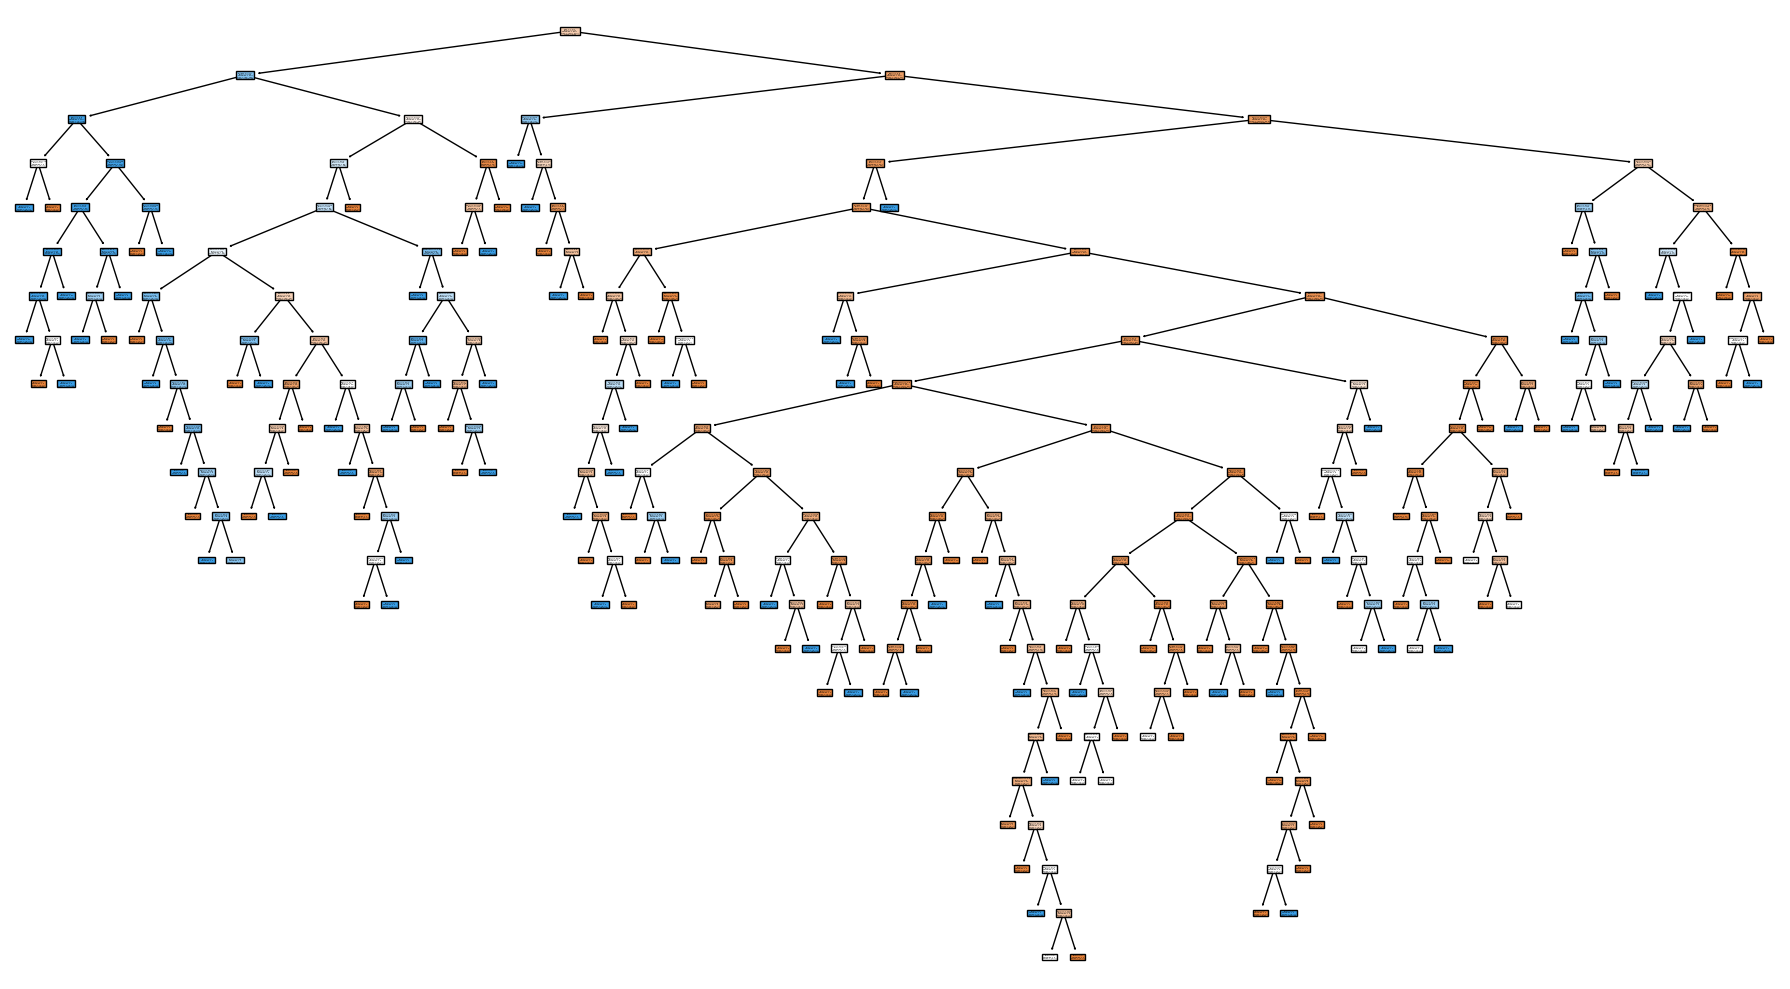

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()    

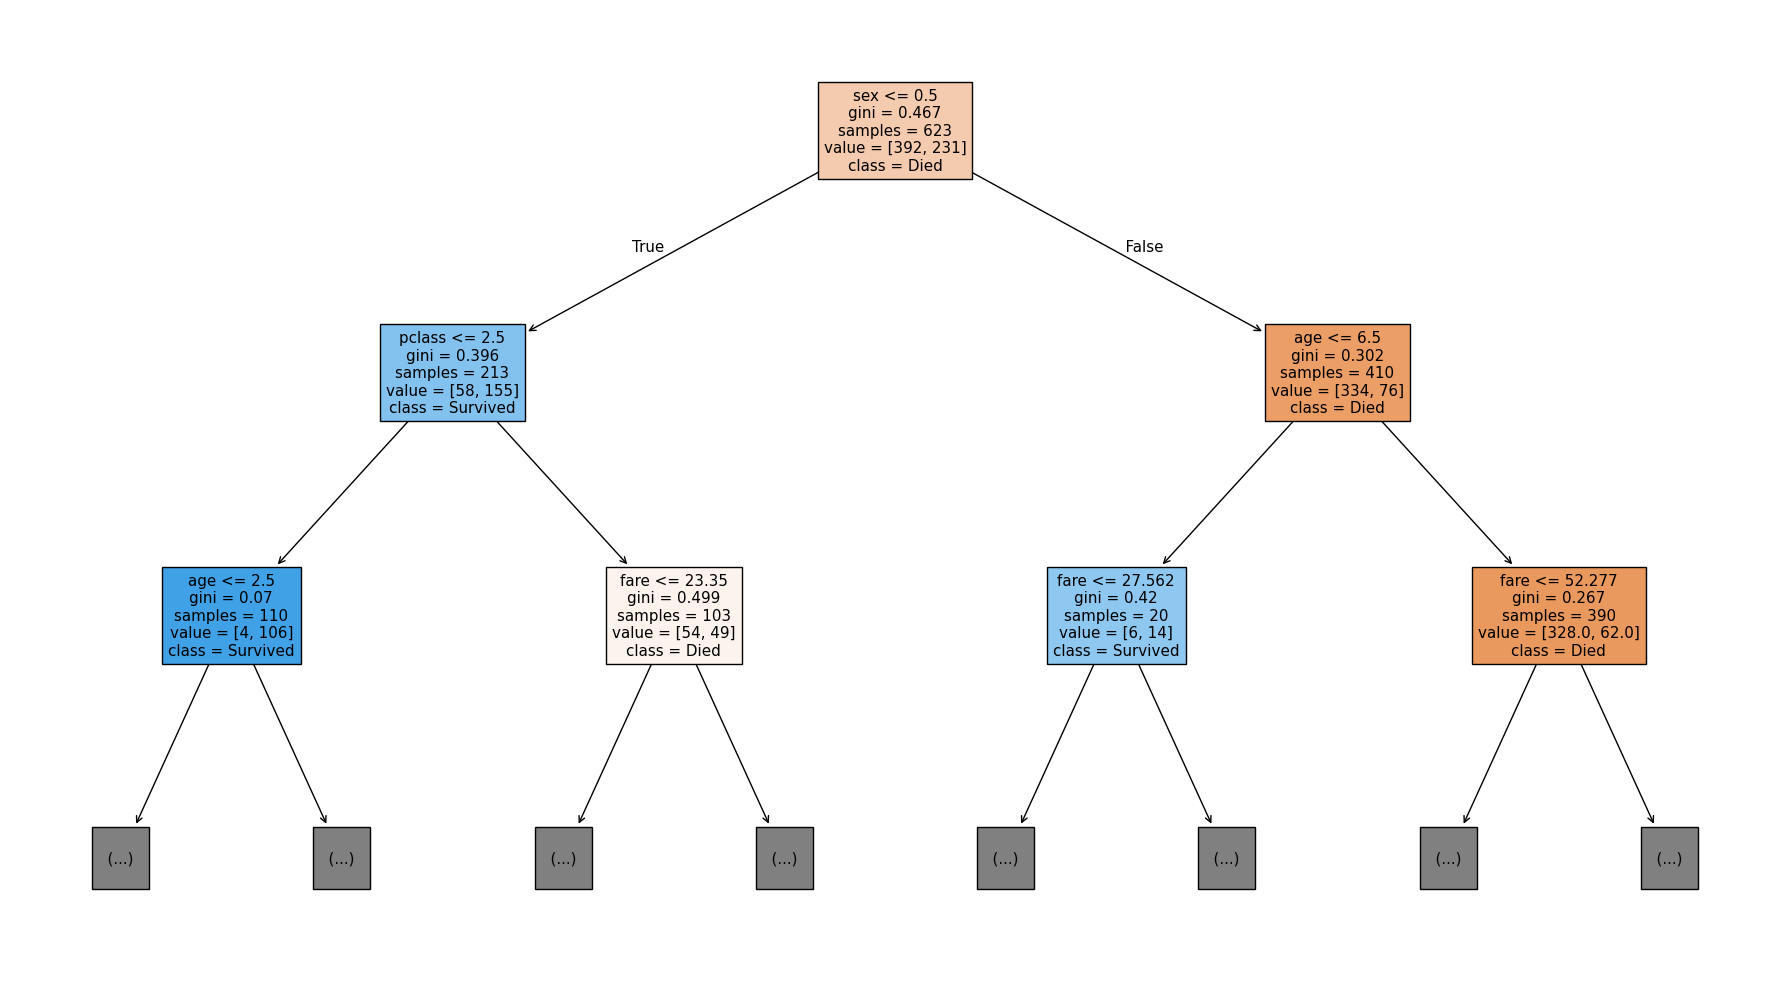

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()    

# Decision Tree with pre-pruning

In [19]:
max_depths=[2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model= DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test) #by default score is used to find accuracy in classifire
    print(f"for depth={depth}, accuracy={acc}")  

for depth=2, accuracy=0.7723880597014925
for depth=3, accuracy=0.8059701492537313
for depth=4, accuracy=0.8246268656716418
for depth=5, accuracy=0.7985074626865671
for depth=6, accuracy=0.7873134328358209
for depth=7, accuracy=0.7835820895522388
for depth=8, accuracy=0.7947761194029851
for depth=9, accuracy=0.7761194029850746
for depth=10, accuracy=0.7947761194029851


In [20]:
min_samples_splits=[5,10,15,20,25,30]

for split in min_samples_splits:
    model= DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test) #by default score is used to find accuracy in classifire
    print(f"for sample split={split}, accuracy={acc}")  

for sample split=5, accuracy=0.8246268656716418
for sample split=10, accuracy=0.8246268656716418
for sample split=15, accuracy=0.8171641791044776
for sample split=20, accuracy=0.8171641791044776
for sample split=25, accuracy=0.8208955223880597
for sample split=30, accuracy=0.8208955223880597


for depth=2, accuracy=0.7723880597014925
for depth=3, accuracy=0.8059701492537313
for depth=4, accuracy=0.8246268656716418
for depth=5, accuracy=0.7947761194029851
for depth=6, accuracy=0.7873134328358209
for depth=7, accuracy=0.7873134328358209
for depth=8, accuracy=0.7910447761194029
for depth=9, accuracy=0.7611940298507462
for depth=10, accuracy=0.7835820895522388


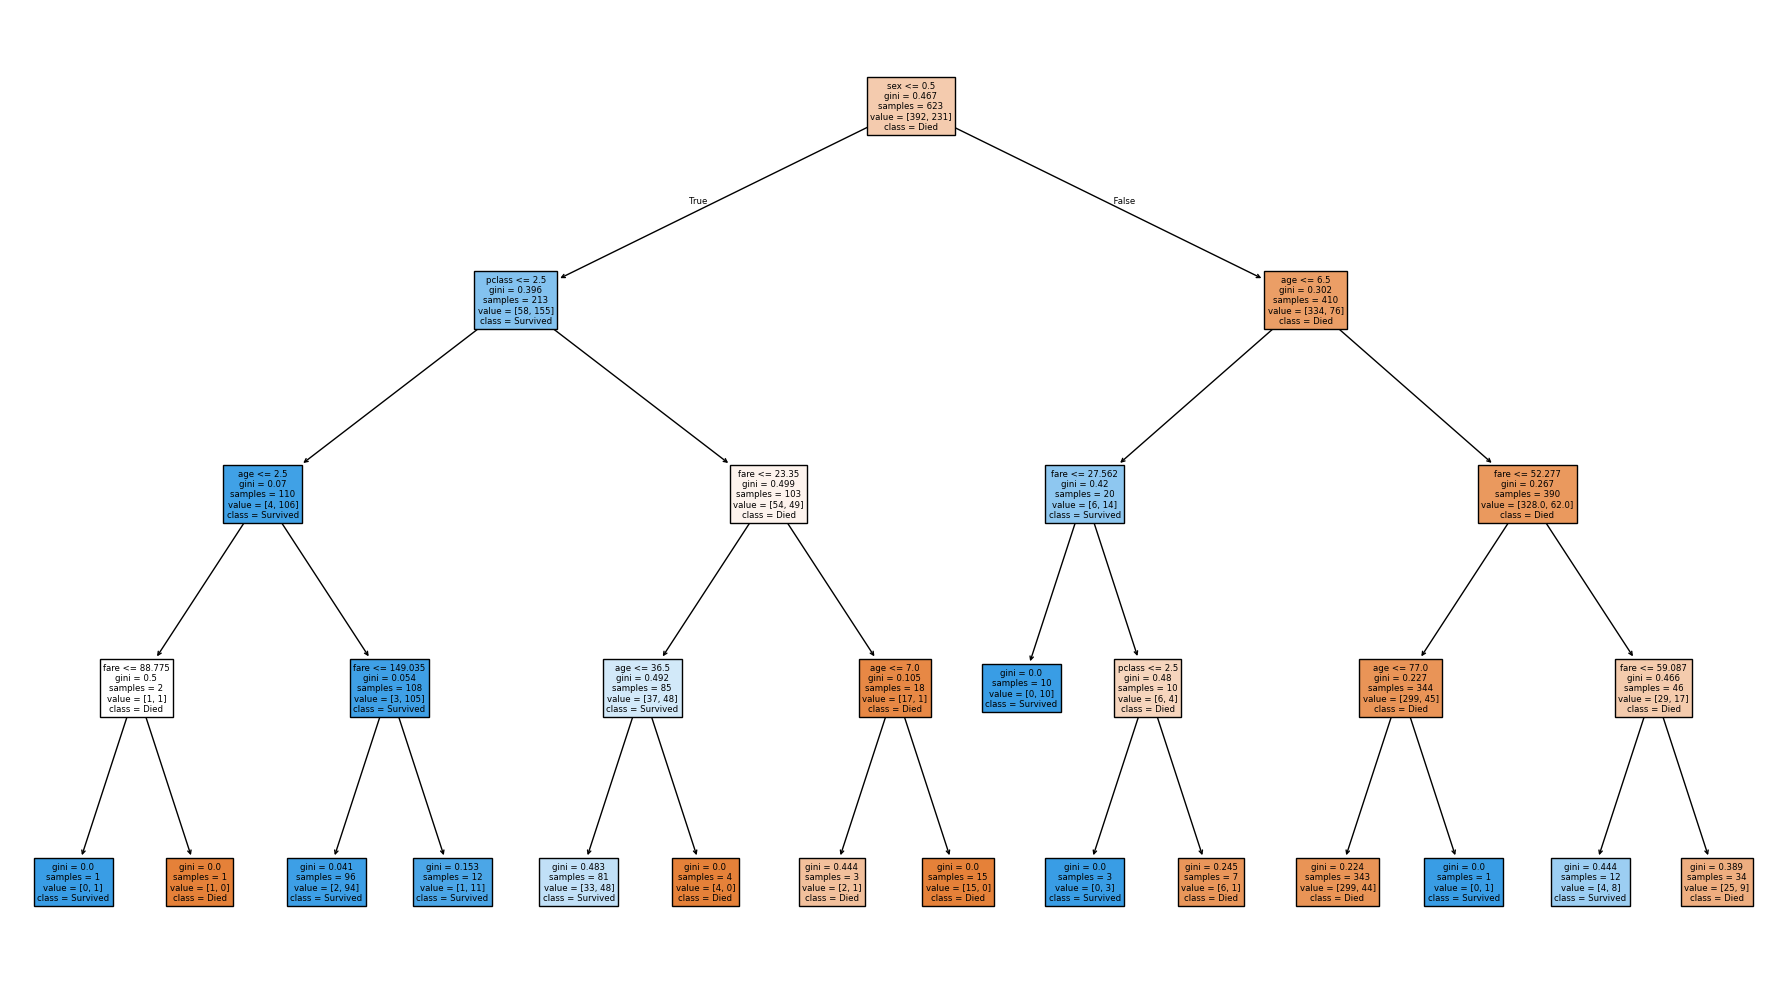

In [21]:
max_depths=[2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model= DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test) #by default score is used to find accuracy in classifire
    print(f"for depth={depth}, accuracy={acc}")  

    if depth==4:
      plt.figure(figsize=(18,10))
      plot_tree(
      model,
      feature_names=X.columns,
      class_names=["Died","Survived"],
      filled=True
      )

plt.tight_layout()
plt.show()     

for sample split=5, accuracy=0.8246268656716418
for sample split=10, accuracy=0.8246268656716418
for sample split=15, accuracy=0.8171641791044776
for sample split=20, accuracy=0.8171641791044776
for sample split=25, accuracy=0.8208955223880597
for sample split=30, accuracy=0.8208955223880597


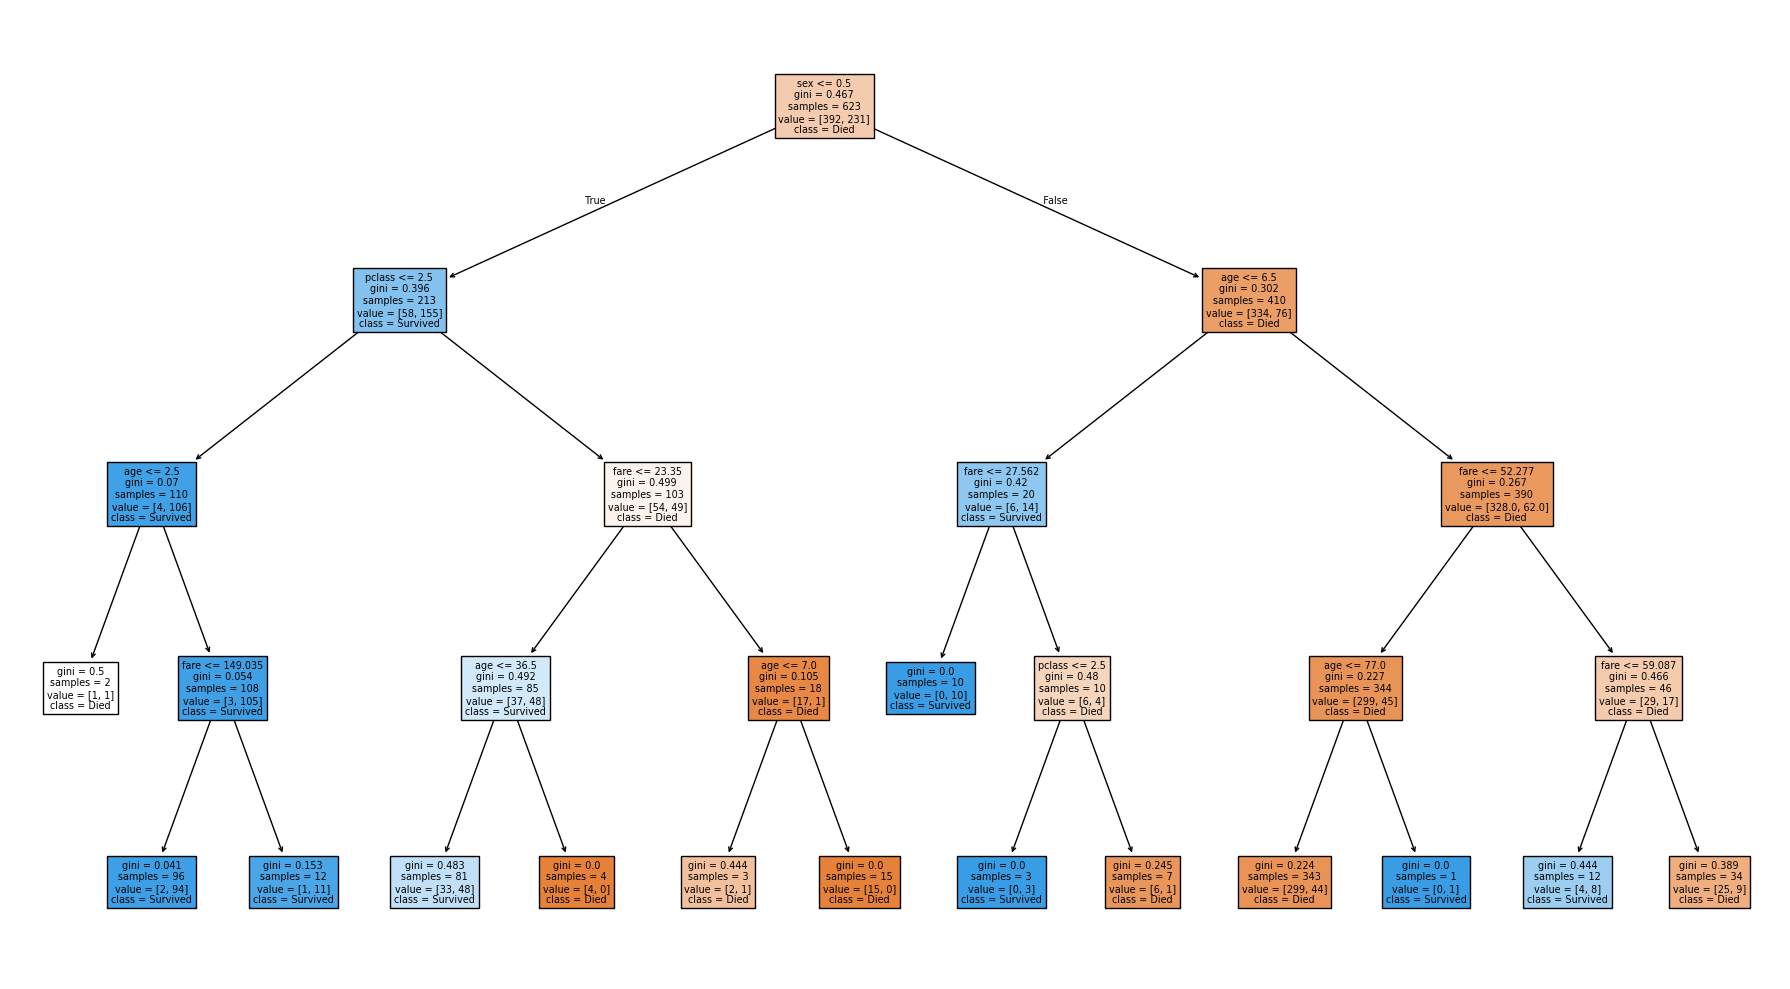

In [22]:
min_samples_splits=[5,10,15,20,25,30]

for split in min_samples_splits:
    model= DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test) #by default score is used to find accuracy in classifire
    print(f"for sample split={split}, accuracy={acc}")  

    if split==10:
      plt.figure(figsize=(18,10))
      plot_tree(
      model,
      feature_names=X.columns,
      class_names=["Died","Survived"],
      filled=True
      )

plt.tight_layout()
plt.show()     

    

# Decision Tree with post-pruning

In [24]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [25]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [26]:
# Train Our model for all alphas 

trees=[]

for alpha in ccp_alphas:
    model= DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)

    trees.append((model,alpha))

In [27]:
best_acc= 0
best_alpha=0

for model,alpha in trees:
    curr_acc=model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc=curr_acc
        best_aplha=alpha
    

In [28]:
best_aplha

0.0017121455323702516

In [29]:
best_acc

0.8208955223880597

In [30]:
best_model=DecisionTreeClassifier(ccp_alpha=best_aplha)
best_model.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=0.0017121455323702516)

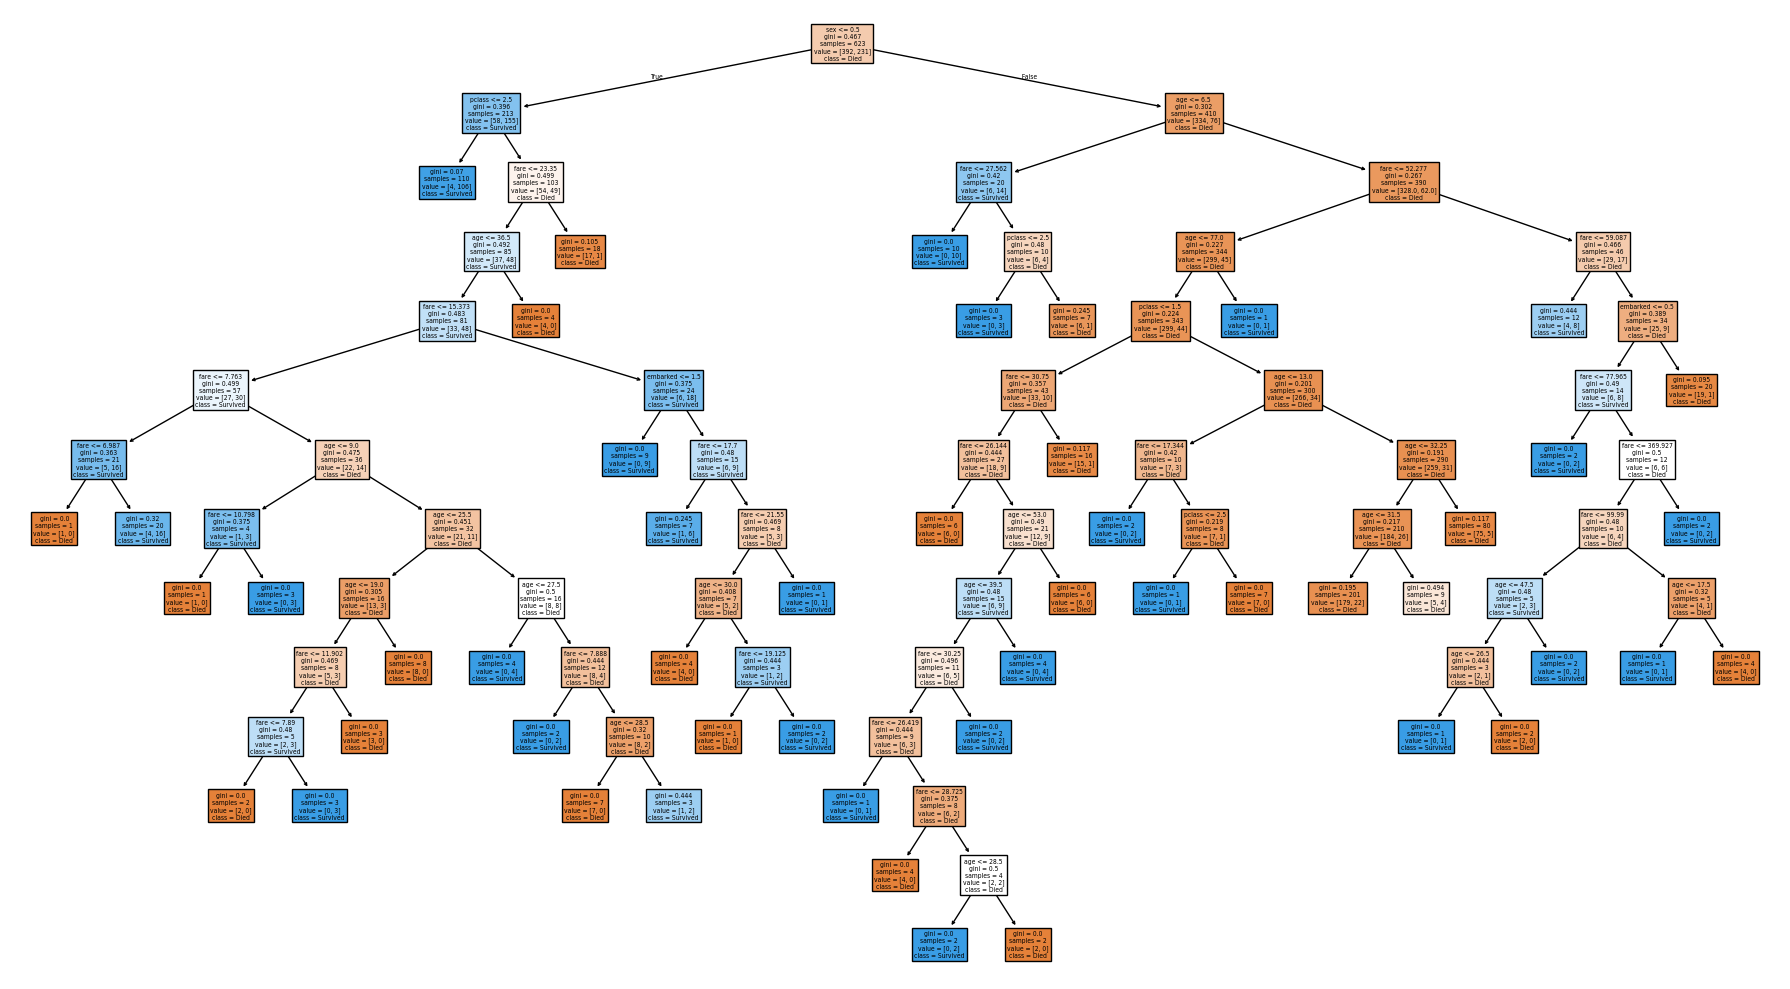

In [31]:
plt.figure(figsize=(18,10))
plot_tree(
      best_model,
      feature_names=X.columns,
      class_names=["Died","Survived"],
      filled=True
      )

plt.tight_layout()
plt.show()     


In [32]:
print(best_model.score(X_test,y_test))

0.8171641791044776


In [63]:
best_model=DecisionTreeClassifier(ccp_alpha=best_aplha,max_depth=4)
best_model.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=0.0017121455323702516, max_depth=4)

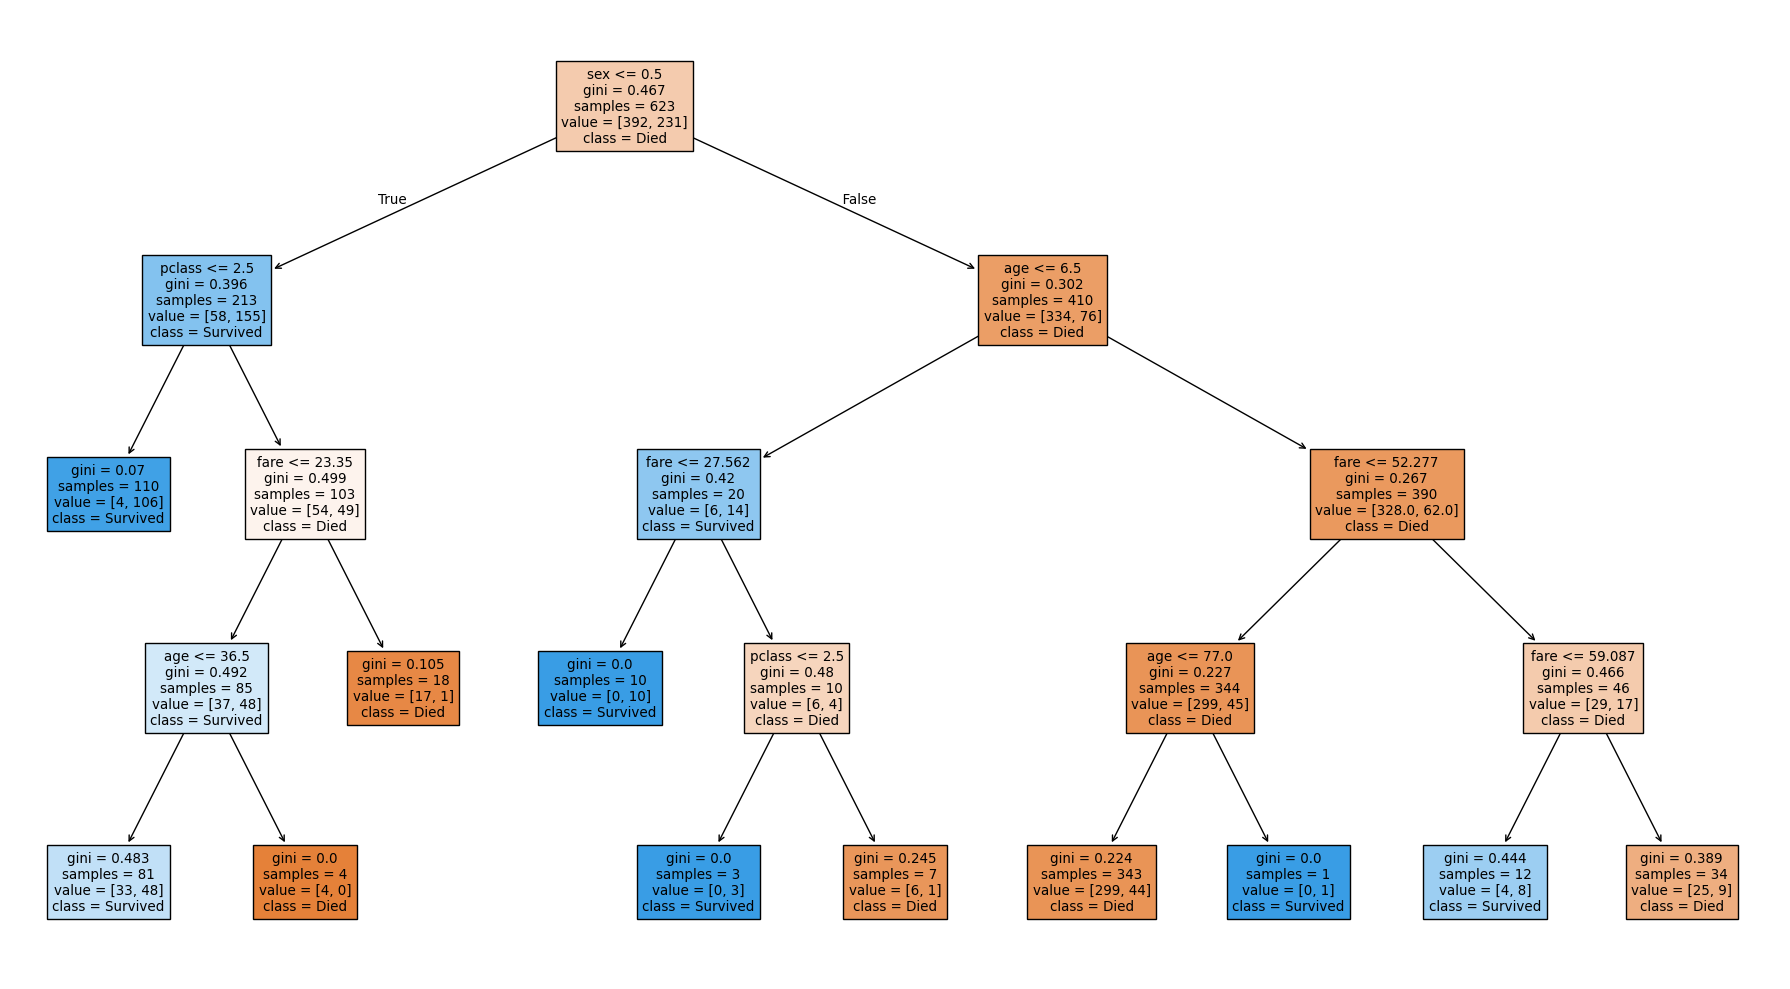

In [65]:
plt.figure(figsize=(18,10))
plot_tree(
      best_model,
      feature_names=X.columns,
      class_names=["Died","Survived"],
      filled=True
      )

plt.tight_layout()
plt.show()     


In [67]:
print(best_model.score(X_test,y_test))

0.8246268656716418
